In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

plt.style.use("ggplot")
DATA_PATH = "../../data/raw_parquet/" 

In [25]:
all_files = glob.glob(os.path.join(DATA_PATH, "**/*.parquet"), recursive=True)
print(f"Total file number: {len(all_files)}")

sample_files = np.random.choice(all_files, min(10, len(all_files)), replace=False)
df_sample = pd.concat([pd.read_parquet(f) for f in sample_files], ignore_index=True)
df_sample = df_sample.sort_values(['icao24', 'timestamp'])

all_icaos = df_sample["icao24"].unique()
selected_icaos = np.random.choice(all_icaos, size=10, replace=False)
df_seq = df_sample[df_sample["icao24"].isin(selected_icaos)].copy()
df_seq = df_seq.sort_values(["icao24", "timestamp"])

print(f"Sample row number: {len(df_sample)}")
print(f"Shape: {df_sample.shape}")
df_sample.head()

Total file number: 1294
Sample row number: 51658
Shape: (51658, 13)


,timestamp,icao24,callsign,lat,lon,alt,velocity,true_track,acceleration,turn_rate,vertical_rate,on_ground,category
44141,2026-04-22 05:28:10,008080,LNK721T,-27.0010,26.9627,10347.96,236.21,226.85,0.077447,-0.000638,4.377447,False,0
44140,2026-04-22 05:28:10,008081,LNK552N,-27.5399,29.4349,10980.42,189.51,328.77,0.024255,0.000638,0.162128,False,0
3565,2026-04-22 06:14:53,00808c,LNK109K,-25.5961,28.6436,7498.08,170.22,213.79,-0.006591,-0.003182,-7.446818,False,0
23760,2026-04-22 04:48:44,00810b,ZSOEE,-26.0524,28.2619,2331.72,81.48,13.51,0.150690,-0.040690,5.780690,False,0
14537,2026-04-22 04:49:14,00810b,ZSOEE,-26.0332,28.2728,2506.98,85.61,56.02,0.137667,1.417000,5.842000,False,0


In [12]:
df_sample.info()
df_sample.describe()

<class 'pandas.DataFrame'>
Index: 68753 entries, 23003 to 59385
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      68753 non-null  datetime64[ms]
 1   icao24         68753 non-null  str           
 2   callsign       68753 non-null  str           
 3   lat            68753 non-null  float64       
 4   lon            68753 non-null  float64       
 5   alt            64154 non-null  float64       
 6   velocity       68735 non-null  float64       
 7   true_track     68753 non-null  float64       
 8   acceleration   68753 non-null  float64       
 9   turn_rate      68753 non-null  float64       
 10  vertical_rate  68753 non-null  float64       
 11  on_ground      68753 non-null  bool          
 12  category       68753 non-null  int64         
dtypes: bool(1), datetime64[ms](1), float64(8), int64(1), str(2)
memory usage: 7.7 MB


,timestamp,lat,lon,alt,velocity,true_track,acceleration,turn_rate,vertical_rate,category
count,68753,68753.000000,68753.000000,64154.000000,68735.000000,68753.000000,68753.000000,68753.000000,68753.000000,68753.000000
mean,2026-04-21 23:04:40.337000,33.589865,-47.029154,6728.815261,159.362300,179.300183,-0.005611,-0.010380,-0.076761,0.265428
min,2026-04-21 19:04:07,-49.206300,-174.327200,-304.800000,0.000000,0.000000,-15.620000,-55.265000,-208.146316,0.000000
25%,2026-04-21 20:10:50,32.361300,-97.052400,1859.280000,75.620000,89.220000,-0.033667,-0.005172,-0.262759,0.000000
50%,2026-04-21 22:30:54,37.716900,-81.208200,7833.360000,194.140000,180.540000,0.000000,0.000000,0.000000,0.000000
75%,2026-04-22 01:47:49,42.506200,2.705200,10972.800000,229.165000,270.000000,0.024889,0.004839,0.000000,0.000000
max,2026-04-22 05:42:15,73.473300,179.691100,14965.680000,388.450000,359.890000,5.430345,64.080000,1257.300000,13.000000
std,NaN,19.070086,78.593970,4431.315960,83.677367,103.362537,0.186057,0.772814,7.170678,1.440975


*count*
- Total Records
- Shows how many valid (non-null) data points you have.

*mean*
- Average Value
- Average velocity is 159 m/s (approx. 550 km/h). This is a normal cruise speed.

*min/max*
- Range
- Velocity max: 388 m/s: This is very fast (Supersonic!). It might be a data outlier or a military jet.

*std*
- Standard Deviation
- Shows the "spread". A high std in acceleration means some planes are changing speed rapidly.

*25% / 50% / 75%*
- Percentiles
- 50% (Median) is the middle value. Half of your planes are flying above 7,315 meters.

---

Critical Observations for Preprocessing
- Acceleration: Min is -15.6 and Max is 5.4. In aviation, +/- 5-7 m/s² is a very sharp change. We should check if these are real maneuvers or sensor noise.
- Turn Rate: Max is 64 degrees per second. This is a very sharp turn (Combat maneuver style!). For a commercial flight, this might be an anomaly.
- Vertical Rate: Max 1257 m/s? This is impossible for a normal climb (that's faster than a rocket!). This confirms we have outliers to clean.

In [13]:
# Check for missing values
print("--- Missing Values Analysis ---")
print(df_sample.isnull().sum())

# Calculate data density per aircraft
print("\n--- Aircraft Data Density ---")
flight_counts = df_sample['icao24'].value_counts()
print(f"Total unique aircraft in sample: {len(flight_counts)}")
print(f"Average records per aircraft: {flight_counts.mean():.2f}")

# Filter for a single flight to see the sequence logic
top_icao = flight_counts.index[0]
print(f"\n--- Detailed Analysis for Aircraft: {top_icao} ---")
single_flight = df_sample[df_sample['icao24'] == top_icao].sort_values('timestamp')
print(single_flight[['timestamp', 'velocity', 'acceleration', 'turn_rate']].head(10))

--- Missing Values Analysis ---
timestamp           0
icao24              0
callsign            0
lat                 0
lon                 0
alt              4599
velocity           18
true_track          0
acceleration        0
turn_rate           0
vertical_rate       0
on_ground           0
category            0
dtype: int64

--- Aircraft Data Density ---
Total unique aircraft in sample: 28025
Average records per aircraft: 2.45

--- Detailed Analysis for Aircraft: 3470c5 ---
                timestamp  velocity  acceleration  turn_rate
68162 2026-04-21 19:26:58       NaN           0.0        0.0
19076 2026-04-21 20:10:50       NaN           0.0        0.0
27936 2026-04-21 20:33:34       NaN           0.0        0.0
46803 2026-04-21 22:30:54       NaN           0.0        0.0
54374 2026-04-21 22:43:04       NaN           0.0        0.0
10144 2026-04-22 00:12:40       NaN           0.0        0.0
39225 2026-04-22 01:47:49       NaN           0.0        0.0
33553 2026-04-22 02:16:39   

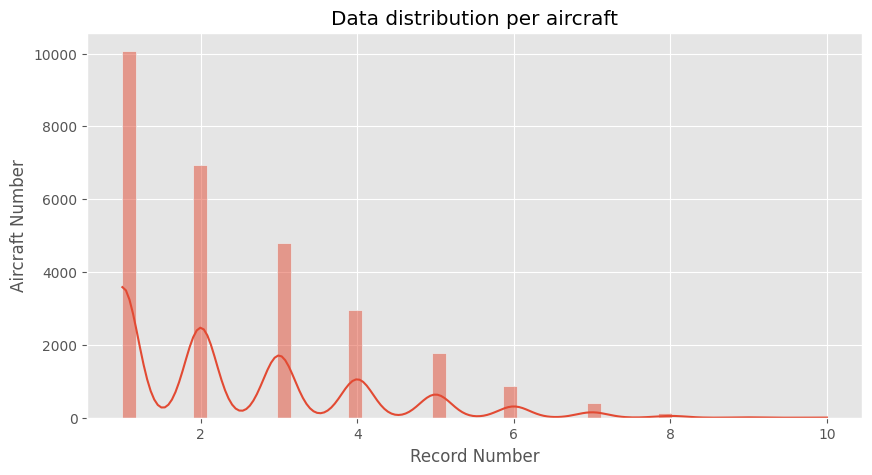

**The number of aircraft records sending the most data.: 10
Number of aircraft appearing only once: 10068


In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(flight_counts, bins=50, kde=True)
plt.title("Data distribution per aircraft")
plt.xlabel("Record Number")
plt.ylabel("Aircraft Number")
plt.show()

print(f"**The number of aircraft records sending the most data.: {flight_counts.max()}")
print(f"Number of aircraft appearing only once: {(flight_counts == 1).sum()}")

--- Visualizing Feature Distributions (Outlier Detection) ---


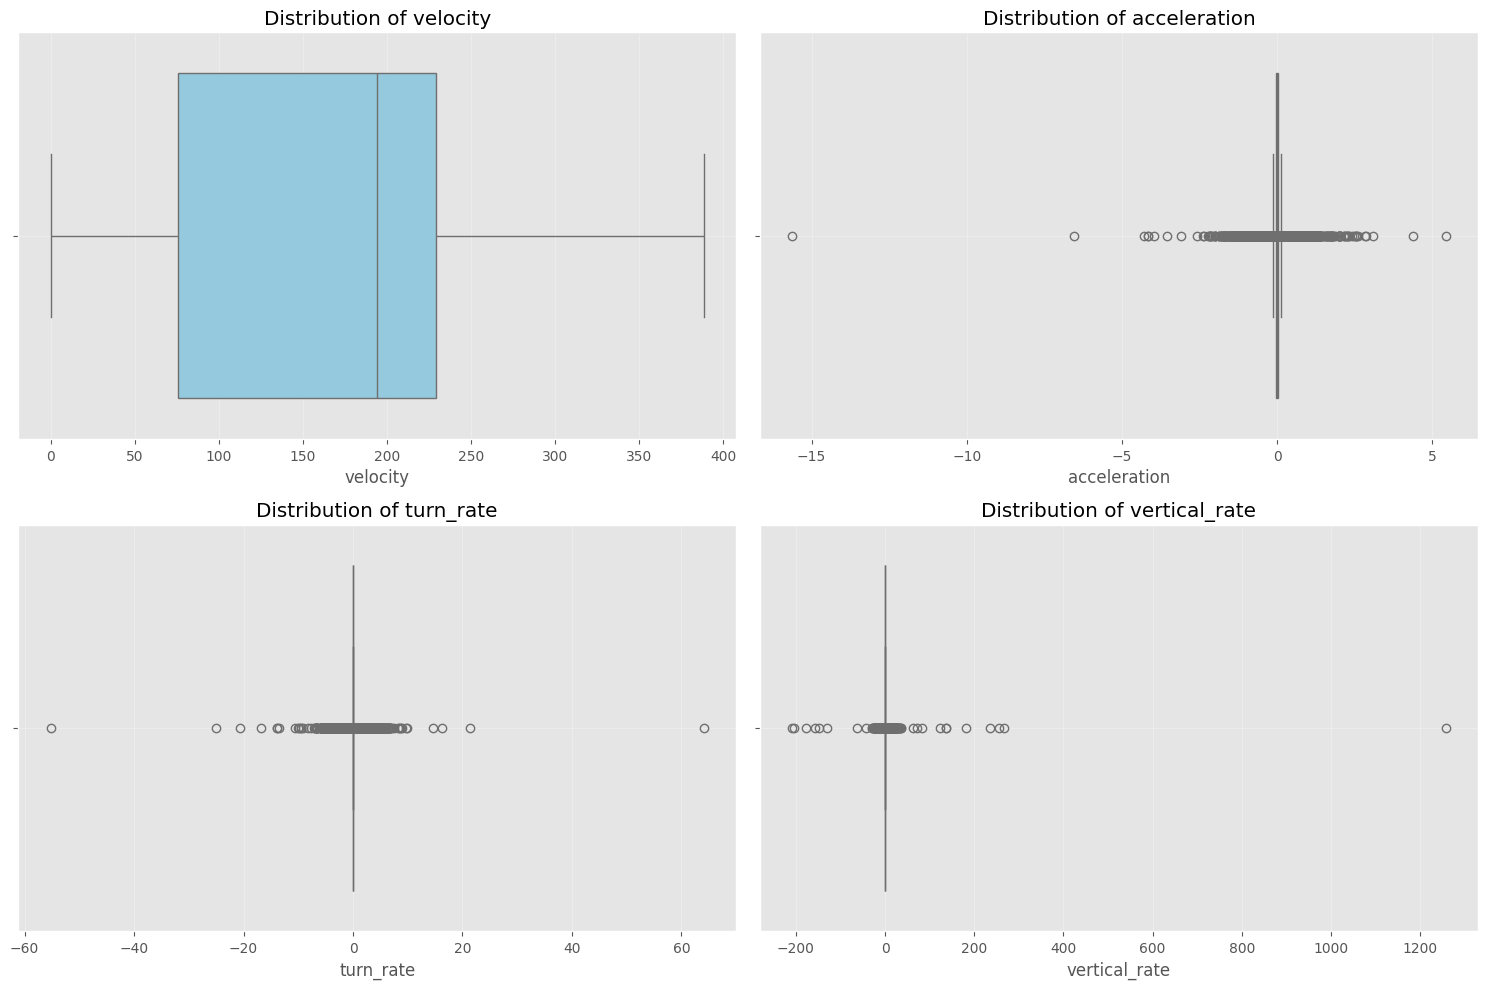


--- Identifying Extreme Outliers ---
Records with vertical_rate > 100 m/s: 14
Records with acceleration > 10 m/s^2: 1


In [15]:
print("--- Visualizing Feature Distributions (Outlier Detection) ---")

# We focus on the calculated physical rates
features = ['velocity', 'acceleration', 'turn_rate', 'vertical_rate']

plt.figure(figsize=(15, 10))

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df_sample, x=col, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detect specific extreme outliers
print("\n--- Identifying Extreme Outliers ---")
extreme_v_rate = df_sample[df_sample['vertical_rate'].abs() > 100].shape[0]
extreme_accel = df_sample[df_sample['acceleration'].abs() > 10].shape[0]

print(f"Records with vertical_rate > 100 m/s: {extreme_v_rate}")
print(f"Records with acceleration > 10 m/s^2: {extreme_accel}")

In [7]:
import tqdm

print("--- Scanning All Files for Global Stats ---")
all_counts = []

for f in tqdm.tqdm(all_files):
    temp_df = pd.read_parquet(f, columns=['icao24']) 
    all_counts.append(temp_df['icao24'].value_counts())

global_counts = pd.concat(all_counts).groupby(level=0).sum()

print(f"\nTotal unique aircraft in ALL data: {len(global_counts)}")
print(f"Top aircraft record count: {global_counts.max()}")
print(f"Average records per aircraft: {global_counts.mean():.2f}")

rich_flights = global_counts[global_counts > 20]
print(f"Aircraft with >20 records: {len(rich_flights)} (These are your gold mine!)")

--- Scanning All Files for Global Stats ---


100%|██████████| 1294/1294 [00:32<00:00, 40.18it/s]



Total unique aircraft in ALL data: 40333
Top aircraft record count: 1294
Average records per aircraft: 204.09
Aircraft with >20 records: 36265 (These are your gold mine!)


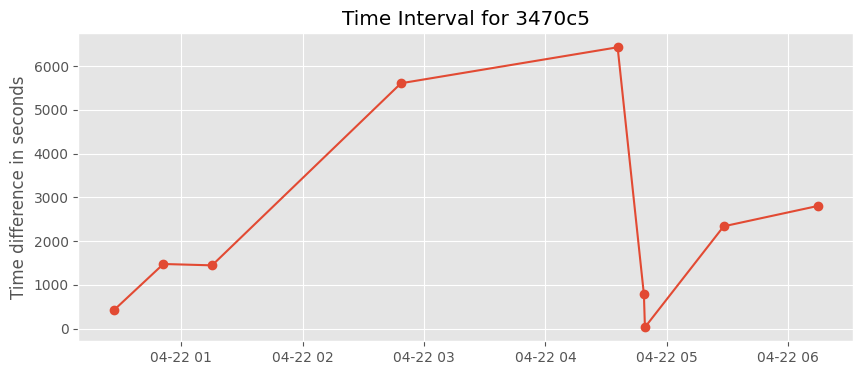

Mean Time Difference: 2369.00 sn


In [27]:
target_icao = flight_counts.index[0] 
test_flight = df_sample[df_sample['icao24'] == target_icao].sort_values('timestamp')

test_flight['time_diff'] = test_flight['timestamp'].diff().dt.total_seconds()

plt.figure(figsize=(10, 4))
plt.plot(test_flight['timestamp'], test_flight['time_diff'], 'o-')
plt.title(f"Time Interval for {target_icao}")
plt.ylabel("Time difference in seconds")
plt.show()

print(f"Mean Time Difference: {test_flight['time_diff'].mean():.2f} sn")

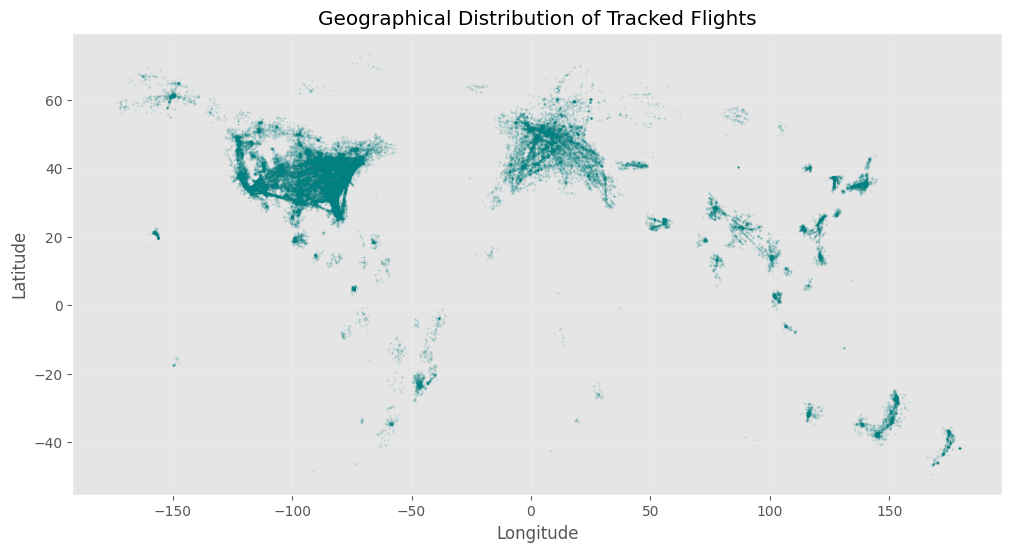

Longitude Range: -174.33 to 179.69
Latitude Range: -49.21 to 73.47


In [17]:
# Scatter plot for geographical distribution
plt.figure(figsize=(12, 6))
plt.scatter(df_sample['lon'], df_sample['lat'], alpha=0.1, s=1, color='teal')
plt.title("Geographical Distribution of Tracked Flights")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.2)
plt.show()

print(f"Longitude Range: {df_sample['lon'].min():.2f} to {df_sample['lon'].max():.2f}")
print(f"Latitude Range: {df_sample['lat'].min():.2f} to {df_sample['lat'].max():.2f}")

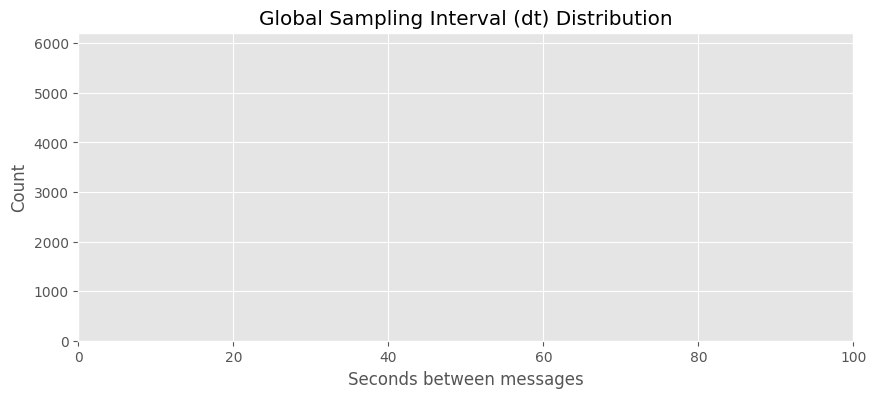

In [23]:
# Global Time Gap (dt) Analysis
df_sample['prev_time'] = df_sample.groupby('icao24')['timestamp'].shift(1)
df_sample['dt'] = (df_sample['timestamp'] - df_sample['prev_time']).dt.total_seconds()

plt.figure(figsize=(10, 4))
sns.histplot(df_sample['dt'].dropna(), bins=100, color='orange', kde=True)
plt.title("Global Sampling Interval (dt) Distribution")
plt.xlabel("Seconds between messages")
plt.xlim(0, 100) 
plt.show()


--- Sequence Length Stats ---
count    10.000000
mean      2.500000
std       1.649916
min       1.000000
25%       1.000000
50%       2.000000
75%       3.750000
max       5.000000
dtype: float64


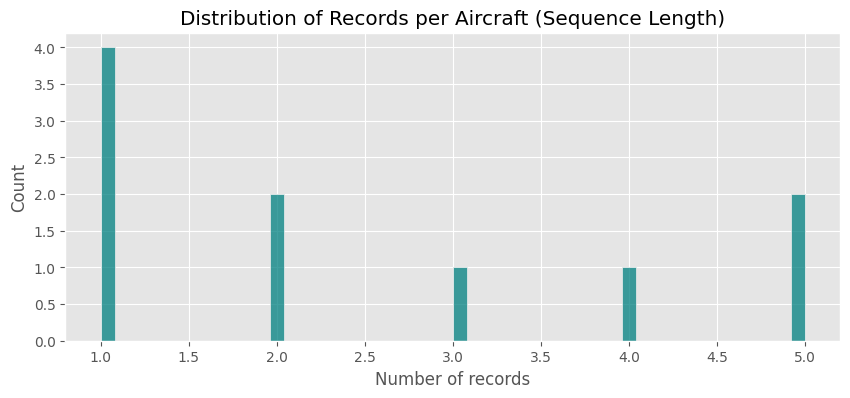

In [28]:
# Sequence Length Distribution 
seq_lengths = df_seq.groupby('icao24').size()
print("\n--- Sequence Length Stats ---")
print(seq_lengths.describe())

plt.figure(figsize=(10, 4))
sns.histplot(seq_lengths, bins=50, color='teal')
plt.title("Distribution of Records per Aircraft (Sequence Length)")
plt.xlabel("Number of records")
plt.show()

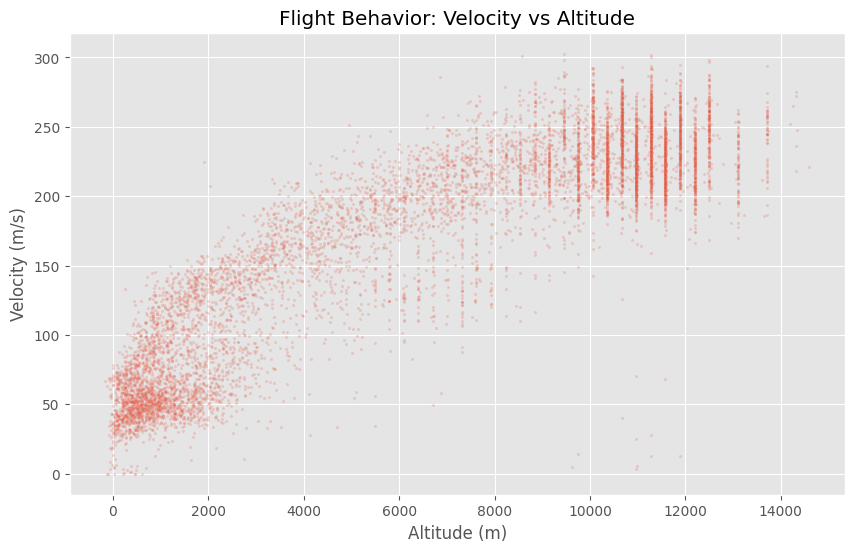

In [20]:
# Feature Relations: Altitude vs Velocity (Feedback 5 & 7)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample.sample(min(10000, len(df_sample))), x='alt', y='velocity', alpha=0.2, s=5)
plt.title("Flight Behavior: Velocity vs Altitude")
plt.xlabel("Altitude (m)")
plt.ylabel("Velocity (m/s)")
plt.show()

In [21]:
# Precise Outlier Analysis 
print("\n--- Percentile Analysis for Noise Detection ---")
for col in ['acceleration', 'turn_rate', 'vertical_rate']:
    quantiles = df_sample[col].quantile([0.001, 0.01, 0.99, 0.999])
    print(f"\n{col.upper()} Quantiles:")
    print(quantiles)


--- Percentile Analysis for Noise Detection ---

ACCELERATION Quantiles:
0.001   -1.399659
0.010   -0.486862
0.990    0.532689
0.999    1.331113
Name: acceleration, dtype: float64

TURN_RATE Quantiles:
0.001   -5.239104
0.010   -2.607586
0.990    2.462556
0.999    4.950828
Name: turn_rate, dtype: float64

VERTICAL_RATE Quantiles:
0.001   -17.969538
0.010   -12.349655
0.990    14.763750
0.999    20.746954
Name: vertical_rate, dtype: float64


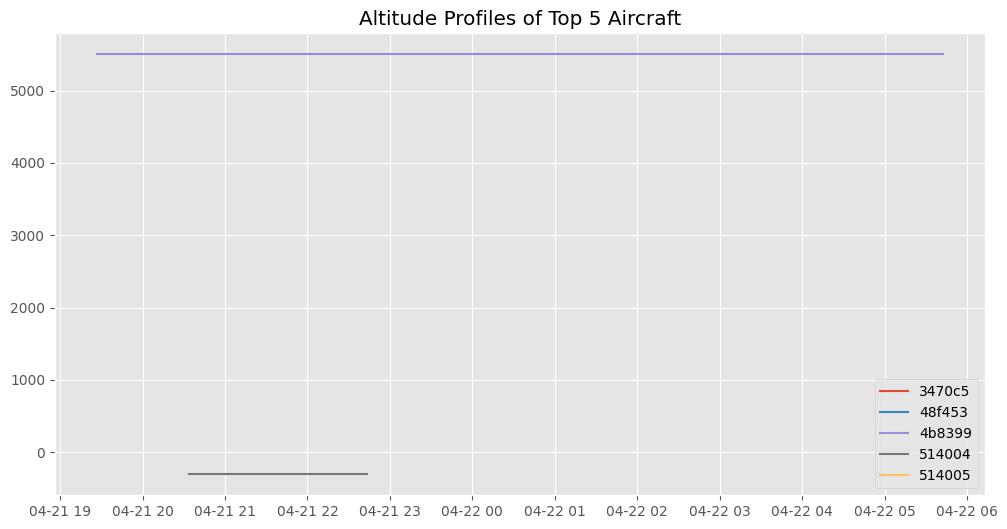

In [22]:
# Altitude vs Time for multiple samples
sample_icaos = df_sample['icao24'].value_counts().head(5).index
plt.figure(figsize=(12, 6))
for icao in sample_icaos:
    sub = df_sample[df_sample['icao24'] == icao]
    plt.plot(sub['timestamp'], sub['alt'], label=icao)
plt.title("Altitude Profiles of Top 5 Aircraft")
plt.legend()
plt.show()

count    22.000000
mean      1.136364
std       0.351250
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       2.000000
dtype: float64


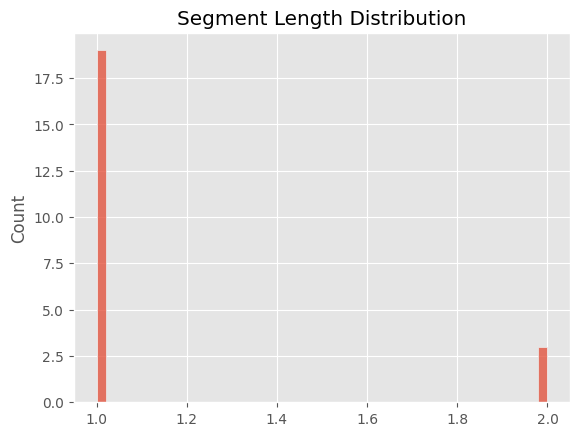

In [29]:
df_seq["prev"] = df_seq.groupby("icao24")["timestamp"].shift(1)
df_seq["dt"] = (df_seq["timestamp"] - df_seq["prev"]).dt.total_seconds()

df_seq["new_segment"] = (df_seq["dt"] > 60) | (df_seq["dt"].isna())

df_seq["segment_id"] = df_seq.groupby("icao24")["new_segment"].cumsum()

segment_lengths = df_seq.groupby(["icao24", "segment_id"]).size()

print(segment_lengths.describe())


sns.histplot(segment_lengths, bins=50)
plt.title("Segment Length Distribution")
plt.show()